In [ ]:
 Cell 1 — Set Directory

In [1]:
import os
os.chdir(r'C:\Users\Nadimul haque\Downloads')
print('Working directory:', os.getcwd())

Working directory: C:\Users\Nadimul haque\Downloads


In [ ]:
Cell 2 — Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
import random

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('All libraries imported successfully!')

All libraries imported successfully!


[nltk_data] Downloading package punkt to C:\Users\Nadimul
[nltk_data]     haque\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Nadimul
[nltk_data]     haque\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Nadimul
[nltk_data]     haque\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Nadimul
[nltk_data]     haque\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [5]:
# Define 5 job roles with required skills
job_roles = {
    'Data Scientist': {
        'required_skills': [
            'python', 'machine learning', 'deep learning', 'statistics',
            'tensorflow', 'keras', 'scikit-learn', 'pandas', 'numpy',
            'data visualization', 'sql', 'nlp', 'computer vision',
            'feature engineering', 'model evaluation'
        ],
        'description': '''We are looking for a Data Scientist with strong
        experience in machine learning, deep learning and statistical analysis.
        Must have proficiency in Python, TensorFlow, Keras and Scikit-learn.
        Experience with NLP, computer vision and feature engineering required.
        Strong SQL and data visualization skills essential.'''
    },
    'Web Developer': {
        'required_skills': [
            'html', 'css', 'javascript', 'react', 'nodejs',
            'restful api', 'mongodb', 'git', 'typescript',
            'responsive design', 'vue.js', 'php', 'mysql',
            'docker', 'agile'
        ],
        'description': '''We are looking for a Web Developer with expertise
        in frontend and backend development. Must have strong skills in HTML,
        CSS, JavaScript, React and NodeJS. Experience with RESTful APIs,
        MongoDB and TypeScript required. Git version control essential.'''
    },
    'ML Engineer': {
        'required_skills': [
            'python', 'machine learning', 'mlops', 'docker',
            'kubernetes', 'tensorflow', 'pytorch', 'aws',
            'model deployment', 'ci/cd', 'spark', 'airflow',
            'feature store', 'model monitoring', 'scikit-learn'
        ],
        'description': '''We are looking for an ML Engineer to build and
        deploy machine learning models at scale. Must have experience with
        MLOps, Docker, Kubernetes and cloud platforms like AWS. Strong
        Python, TensorFlow and PyTorch skills required.'''
    },
    'Data Analyst': {
        'required_skills': [
            'sql', 'excel', 'python', 'tableau', 'power bi',
            'data cleaning', 'statistics', 'pandas', 'numpy',
            'data visualization', 'reporting', 'dashboard',
            'business intelligence', 'etl', 'google analytics'
        ],
        'description': '''We are looking for a Data Analyst with strong
        analytical skills. Must have expertise in SQL, Excel, Tableau and
        Power BI. Experience with Python, data cleaning and statistical
        analysis required. Business intelligence and ETL experience preferred.'''
    },
    'DevOps Engineer': {
        'required_skills': [
            'docker', 'kubernetes', 'aws', 'linux', 'ci/cd',
            'jenkins', 'terraform', 'ansible', 'git', 'bash',
            'monitoring', 'networking', 'security', 'azure', 'gcp'
        ],
        'description': '''We are looking for a DevOps Engineer with strong
        infrastructure and automation skills. Must have expertise in Docker,
        Kubernetes, AWS and CI/CD pipelines. Experience with Jenkins,
        Terraform, Ansible and Linux administration required.'''
    }
}

print('Job Roles defined successfully!')
print(f'\n Total Job Roles: {len(job_roles)}')
for role, details in job_roles.items():
    print(f'\n {role}')
    print(f'   Required Skills: {len(details["required_skills"])} skills')
    print(f'   Skills: {", ".join(details["required_skills"][:5])}...')

Job Roles defined successfully!

 Total Job Roles: 5

 Data Scientist
   Required Skills: 15 skills
   Skills: python, machine learning, deep learning, statistics, tensorflow...

 Web Developer
   Required Skills: 15 skills
   Skills: html, css, javascript, react, nodejs...

 ML Engineer
   Required Skills: 15 skills
   Skills: python, machine learning, mlops, docker, kubernetes...

 Data Analyst
   Required Skills: 15 skills
   Skills: sql, excel, python, tableau, power bi...

 DevOps Engineer
   Required Skills: 15 skills
   Skills: docker, kubernetes, aws, linux, ci/cd...


In [ ]:
Cell 4 — Generate Realistic Resume Dataset

In [9]:
random.seed(42)
np.random.seed(42)

print('Generating dataset...')

# Skills for each role
all_skills = {
    'Data Scientist': ['python', 'machine learning', 'deep learning',
        'statistics', 'tensorflow', 'keras', 'scikit-learn', 'pandas',
        'numpy', 'data visualization', 'sql', 'nlp', 'computer vision',
        'feature engineering', 'model evaluation', 'matplotlib',
        'seaborn', 'jupyter', 'git', 'r programming'],

    'Web Developer': ['html', 'css', 'javascript', 'react', 'nodejs',
        'restful api', 'mongodb', 'git', 'typescript', 'responsive design',
        'vue.js', 'php', 'mysql', 'docker', 'agile', 'bootstrap',
        'jquery', 'graphql', 'webpack', 'sass'],

    'ML Engineer': ['python', 'machine learning', 'mlops', 'docker',
        'kubernetes', 'tensorflow', 'pytorch', 'aws', 'model deployment',
        'ci/cd', 'spark', 'airflow', 'feature store', 'model monitoring',
        'scikit-learn', 'flask', 'fastapi', 'redis', 'kafka', 'git'],

    'Data Analyst': ['sql', 'excel', 'python', 'tableau', 'power bi',
        'data cleaning', 'statistics', 'pandas', 'numpy',
        'data visualization', 'reporting', 'dashboard',
        'business intelligence', 'etl', 'google analytics',
        'looker', 'r programming', 'pivot tables', 'vlookup', 'git'],

    'DevOps Engineer': ['docker', 'kubernetes', 'aws', 'linux', 'ci/cd',
        'jenkins', 'terraform', 'ansible', 'git', 'bash', 'monitoring',
        'networking', 'security', 'azure', 'gcp', 'prometheus',
        'grafana', 'helm', 'nginx', 'python']
}

education_levels = ['Bachelor', 'Master', 'PhD', 'Diploma']
universities = ['MIT', 'Stanford University', 'Harvard University',
    'University of Oxford', 'University of Cambridge', 'IIT Delhi',
    'NUS Singapore', 'University of Toronto', 'ETH Zurich',
    'Carnegie Mellon University', 'University of Manchester',
    'University of Sussex', 'Georgia Tech', 'UC Berkeley',
    'Columbia University']

first_names = ['James', 'Sarah', 'Michael', 'Emily', 'David',
    'Jessica', 'Daniel', 'Ashley', 'Matthew', 'Amanda',
    'Rahul', 'Priya', 'Ahmed', 'Fatima', 'Chen',
    'Carlos', 'Maria', 'John', 'Emma', 'Syed']

last_names = ['Smith', 'Johnson', 'Williams', 'Brown', 'Jones',
    'Garcia', 'Miller', 'Davis', 'Wilson', 'Taylor',
    'Kumar', 'Patel', 'Hassan', 'Ali', 'Zhang',
    'Rodriguez', 'Martinez', 'Anderson', 'Thomas', 'Haque']

print('Variables defined!')
print(f'Roles: {list(all_skills.keys())}')

Generating dataset...
Variables defined!
Roles: ['Data Scientist', 'Web Developer', 'ML Engineer', 'Data Analyst', 'DevOps Engineer']


In [ ]:
Cell 5 — Generate Resumes

In [11]:
def generate_resume(candidate_id, target_role):
    name = f"{random.choice(first_names)} {random.choice(last_names)}"
    years_exp = random.randint(0, 12)
    education = random.choice(education_levels)
    university = random.choice(universities)

    # Candidate skills from role
    role_skills = all_skills[target_role]
    num_skills = random.randint(int(len(role_skills)*0.4), len(role_skills))
    candidate_skills = random.sample(role_skills, num_skills)

    # Add some skills from other roles
    other_roles = [r for r in all_skills.keys() if r != target_role]
    for r in random.sample(other_roles, 2):
        candidate_skills += random.sample(all_skills[r], 2)
    candidate_skills = list(set(candidate_skills))

    # Resume text
    resume_text = f"""
Name: {name}
Experience: {years_exp} years
Education: {education} in Computer Science from {university}
Skills: {', '.join(candidate_skills)}

Professional Summary:
Experienced {target_role} with {years_exp} years of industry experience.
Proficient in {', '.join(candidate_skills[:5])}.
Strong background in {education} level education from {university}.

Work Experience:
{years_exp} years working with {', '.join(candidate_skills[:8])}.
Developed solutions using {', '.join(candidate_skills[:4])}.
Collaborated on projects involving {', '.join(candidate_skills[2:6])}.

Projects:
- Built pipeline using {', '.join(candidate_skills[:3])}
- Developed {target_role} solution using {', '.join(candidate_skills[1:4])}
- Implemented automation using {', '.join(candidate_skills[:2])}

Certifications:
- Certified in {candidate_skills[0].title()} — 2022
- {candidate_skills[1].title()} Professional Certificate — 2023
    """

    return {
        'Candidate_ID': candidate_id,
        'Name': name,
        'Target_Role': target_role,
        'Years_Experience': years_exp,
        'Education': education,
        'University': university,
        'Skills': ', '.join(candidate_skills),
        'Resume_Text': resume_text.strip(),
        'Num_Skills': len(candidate_skills)
    }

# Generate 200 resumes
resumes = []
candidate_id = 1001

for role in job_roles.keys():
    for _ in range(40):
        resume = generate_resume(candidate_id, role)
        resumes.append(resume)
        candidate_id += 1

df = pd.DataFrame(resumes)
df.to_csv('resume_dataset.csv', index=False)

print(' Resume dataset generated!')
print(f' Total Resumes : {len(df)}')
print(f' Job Roles     : {df["Target_Role"].nunique()}')
print(f'\n Resumes per Role:')
print(df['Target_Role'].value_counts())
print(f'\n Sample Resume:')
print(df['Resume_Text'].iloc[0][:400])

 Resume dataset generated!
 Total Resumes : 200
 Job Roles     : 5

 Resumes per Role:
Target_Role
Data Scientist     40
Web Developer      40
ML Engineer        40
Data Analyst       40
DevOps Engineer    40
Name: count, dtype: int64

 Sample Resume:
Name: Emily Smith
Experience: 11 years
Education: PhD in Computer Science from University of Oxford
Skills: nlp, git, graphql, statistics, deep learning, numpy, etl, python, pandas, feature engineering, model evaluation, tensorflow, mongodb, jupyter, machine learning

Professional Summary:
Experienced Data Scientist with 11 years of industry experience.
Proficient in nlp, git, graphql, statistics,


In [ ]:
Cell 6 — Explore Dataset

In [13]:
print(' Dataset Info:')
print(df.info())
print('\n Sample Data:')
print(df[['Candidate_ID', 'Name', 'Target_Role',
          'Years_Experience', 'Education', 'Num_Skills']].head(10))
print('\n Experience Statistics:')
print(df['Years_Experience'].describe())
print('\n Education Distribution:')
print(df['Education'].value_counts())
print('\n Average Skills per Role:')
print(df.groupby('Target_Role')['Num_Skills'].mean().round(2))

 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Candidate_ID      200 non-null    int64 
 1   Name              200 non-null    object
 2   Target_Role       200 non-null    object
 3   Years_Experience  200 non-null    int64 
 4   Education         200 non-null    object
 5   University        200 non-null    object
 6   Skills            200 non-null    object
 7   Resume_Text       200 non-null    object
 8   Num_Skills        200 non-null    int64 
dtypes: int64(3), object(6)
memory usage: 14.2+ KB
None

 Sample Data:
   Candidate_ID              Name     Target_Role  Years_Experience Education  \
0          1001       Emily Smith  Data Scientist                11       PhD   
1          1002       Chen Thomas  Data Scientist                 4  Bachelor   
2          1003       Emma Miller  Data Scientist            

In [ ]:
Cell 7 — Text Cleaning & Parsing

In [15]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_resume(text):
    # Lowercase
    text = text.lower()
    # Remove special characters & numbers
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    # Remove extra whitespace
    text = text.strip()
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords & lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens
              if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

print(' Cleaning resumes...')
df['Cleaned_Resume'] = df['Resume_Text'].apply(clean_resume)

print(' Text cleaning complete!')
print(f'\n Original Resume (first 200 chars):')
print(df['Resume_Text'].iloc[0][:200])
print(f'\n Cleaned Resume (first 200 chars):')
print(df['Cleaned_Resume'].iloc[0][:200])
print(f'\n Avg length before: {df["Resume_Text"].str.len().mean():.0f} chars')
print(f' Avg length after : {df["Cleaned_Resume"].str.len().mean():.0f} chars')

 Cleaning resumes...
 Text cleaning complete!

 Original Resume (first 200 chars):
Name: Emily Smith
Experience: 11 years
Education: PhD in Computer Science from University of Oxford
Skills: nlp, git, graphql, statistics, deep learning, numpy, etl, python, pandas, feature engineerin

 Cleaned Resume (first 200 chars):
name emily smith experience year education phd computer science university oxford skill nlp git graphql statistic deep learning numpy etl python panda feature engineering model evaluation tensorflow m

 Avg length before: 1012 chars
 Avg length after : 862 chars


In [ ]:
Cell 8 — Skill Extraction

In [17]:
def extract_skills(resume_text, all_skill_list):
    resume_lower = resume_text.lower()
    found_skills = []
    for skill in all_skill_list:
        if skill.lower() in resume_lower:
            found_skills.append(skill)
    return found_skills

# All unique skills across all roles
all_skills_flat = list(set([
    skill for skills in all_skills.values()
    for skill in skills
]))

print(' Extracting skills from resumes...')
df['Extracted_Skills'] = df['Resume_Text'].apply(
    lambda x: extract_skills(x, all_skills_flat))
df['Extracted_Skills_Count'] = df['Extracted_Skills'].apply(len)

print(' Skill extraction complete!')
print(f'\n Sample Skill Extraction:')
for i in range(3):
    print(f'\nCandidate: {df["Name"].iloc[i]}')
    print(f'Role     : {df["Target_Role"].iloc[i]}')
    print(f'Skills   : {df["Extracted_Skills"].iloc[i]}')
    print(f'Count    : {df["Extracted_Skills_Count"].iloc[i]}')

 Extracting skills from resumes...
 Skill extraction complete!

 Sample Skill Extraction:

Candidate: Emily Smith
Role     : Data Scientist
Skills   : ['mongodb', 'jupyter', 'machine learning', 'deep learning', 'tensorflow', 'pandas', 'numpy', 'git', 'graphql', 'nlp', 'python', 'feature engineering', 'statistics', 'etl', 'model evaluation']
Count    : 15

Candidate: Chen Thomas
Role     : Data Scientist
Skills   : ['helm', 'php', 'jupyter', 'machine learning', 'deep learning', 'computer vision', 'seaborn', 'tensorflow', 'r programming', 'keras', 'bash', 'pandas', 'numpy', 'git', 'scikit-learn', 'nlp', 'python', 'sass', 'feature engineering', 'matplotlib', 'statistics', 'data visualization', 'sql', 'model evaluation']
Count    : 24

Candidate: Emma Miller
Role     : Data Scientist
Skills   : ['jupyter', 'machine learning', 'aws', 'deep learning', 'computer vision', 'seaborn', 'tensorflow', 'r programming', 'keras', 'pandas', 'numpy', 'git', 'google analytics', 'scikit-learn', 'nlp', 'py

In [ ]:
Cell 9 — TF-IDF Vectorization & Cosine Similarity Scoring

In [19]:
# Clean job descriptions
print('Vectorizing resumes and job descriptions...')

# Prepare job description texts
job_descriptions = {role: details['description'] 
                   for role, details in job_roles.items()}

# Clean job descriptions
cleaned_jd = {role: clean_resume(desc) 
              for role, desc in job_descriptions.items()}

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

# Combine all resumes + job descriptions for fitting
all_texts = list(df['Cleaned_Resume']) + list(cleaned_jd.values())
tfidf.fit(all_texts)

# Transform resumes
resume_vectors = tfidf.transform(df['Cleaned_Resume'])

print('TF-IDF Vectorization complete!')
print(f'Resume Matrix Shape : {resume_vectors.shape}')
print(f'Total Features      : {resume_vectors.shape[1]}')

Vectorizing resumes and job descriptions...
TF-IDF Vectorization complete!
Resume Matrix Shape : (200, 2086)
Total Features      : 2086


In [ ]:
Cell 10 — Candidate Ranking (Cosine Similarity)

In [21]:
print('Ranking candidates for each job role...')

# Score each candidate against each job role
for role in job_roles.keys():
    # Vectorize job description
    jd_vector = tfidf.transform([cleaned_jd[role]])
    
    # Compute cosine similarity
    similarities = cosine_similarity(resume_vectors, jd_vector)
    df[f'Score_{role.replace(" ", "_")}'] = similarities.flatten()

# Get best matching role for each candidate
score_cols = [f'Score_{role.replace(" ", "_")}' 
              for role in job_roles.keys()]
df['Best_Match_Role'] = df[score_cols].idxmax(axis=1)\
    .str.replace('Score_', '').str.replace('_', ' ')
df['Best_Match_Score'] = df[score_cols].max(axis=1)

# Overall match score for target role
df['Target_Role_Score'] = df.apply(
    lambda row: row[f'Score_{row["Target_Role"].replace(" ", "_")}'],
    axis=1)

# Normalize score to percentage
scaler = MinMaxScaler(feature_range=(0, 100))
df['Match_Percentage'] = scaler.fit_transform(
    df[['Target_Role_Score']]).flatten()

print(' Candidate ranking complete!')
print(f'\n Sample Rankings:')
print(df[['Name', 'Target_Role', 'Target_Role_Score',
          'Match_Percentage']].head(10).to_string(index=False))

Ranking candidates for each job role...
 Candidate ranking complete!

 Sample Rankings:
            Name    Target_Role  Target_Role_Score  Match_Percentage
     Emily Smith Data Scientist           0.099743         58.081570
     Chen Thomas Data Scientist           0.150728         93.221158
     Emma Miller Data Scientist           0.139871         85.738668
Matthew Anderson Data Scientist           0.127276         77.057625
 Maria Rodriguez Data Scientist           0.132713         80.805557
     Rahul Brown Data Scientist           0.097484         56.524721
    Priya Taylor Data Scientist           0.112561         66.916352
     Emily Davis Data Scientist           0.053714         26.357997
     Maria Davis Data Scientist           0.078903         43.718697
   Daniel Miller Data Scientist           0.120577         72.441018


In [ ]:
Cell 11 — Skill Gap Identification

In [23]:
def identify_skill_gap(candidate_skills, required_skills):
    candidate_lower = [s.lower() for s in candidate_skills]
    matched   = [s for s in required_skills if s.lower() in candidate_lower]
    missing   = [s for s in required_skills if s.lower() not in candidate_lower]
    return matched, missing

print('Identifying skill gaps...')

matched_list = []
missing_list = []

for _, row in df.iterrows():
    required = job_roles[row['Target_Role']]['required_skills']
    candidate_skills = row['Extracted_Skills']
    matched, missing = identify_skill_gap(candidate_skills, required)
    matched_list.append(matched)
    missing_list.append(missing)

df['Matched_Skills']     = matched_list
df['Missing_Skills']     = missing_list
df['Matched_Skills_Count'] = df['Matched_Skills'].apply(len)
df['Missing_Skills_Count'] = df['Missing_Skills'].apply(len)
df['Skill_Match_Pct']    = (df['Matched_Skills_Count'] /
                            df['Matched_Skills_Count'].add(
                            df['Missing_Skills_Count'])) * 100

print('Skill gap identification complete!')
print(f'\n Sample Skill Gap Analysis:')
for i in range(3):
    print(f'\nCandidate  : {df["Name"].iloc[i]}')
    print(f'Role       : {df["Target_Role"].iloc[i]}')
    print(f'Matched    : {df["Matched_Skills"].iloc[i]}')
    print(f'Missing    : {df["Missing_Skills"].iloc[i]}')
    print(f'Match %    : {df["Skill_Match_Pct"].iloc[i]:.1f}%')

Identifying skill gaps...
Skill gap identification complete!

 Sample Skill Gap Analysis:

Candidate  : Emily Smith
Role       : Data Scientist
Matched    : ['python', 'machine learning', 'deep learning', 'statistics', 'tensorflow', 'pandas', 'numpy', 'nlp', 'feature engineering', 'model evaluation']
Missing    : ['keras', 'scikit-learn', 'data visualization', 'sql', 'computer vision']
Match %    : 66.7%

Candidate  : Chen Thomas
Role       : Data Scientist
Matched    : ['python', 'machine learning', 'deep learning', 'statistics', 'tensorflow', 'keras', 'scikit-learn', 'pandas', 'numpy', 'data visualization', 'sql', 'nlp', 'computer vision', 'feature engineering', 'model evaluation']
Missing    : []
Match %    : 100.0%

Candidate  : Emma Miller
Role       : Data Scientist
Matched    : ['python', 'machine learning', 'deep learning', 'statistics', 'tensorflow', 'keras', 'scikit-learn', 'pandas', 'numpy', 'data visualization', 'sql', 'nlp', 'computer vision', 'feature engineering']
Missin

In [ ]:
Cell 12 — EDA Chart 1 (Overview)

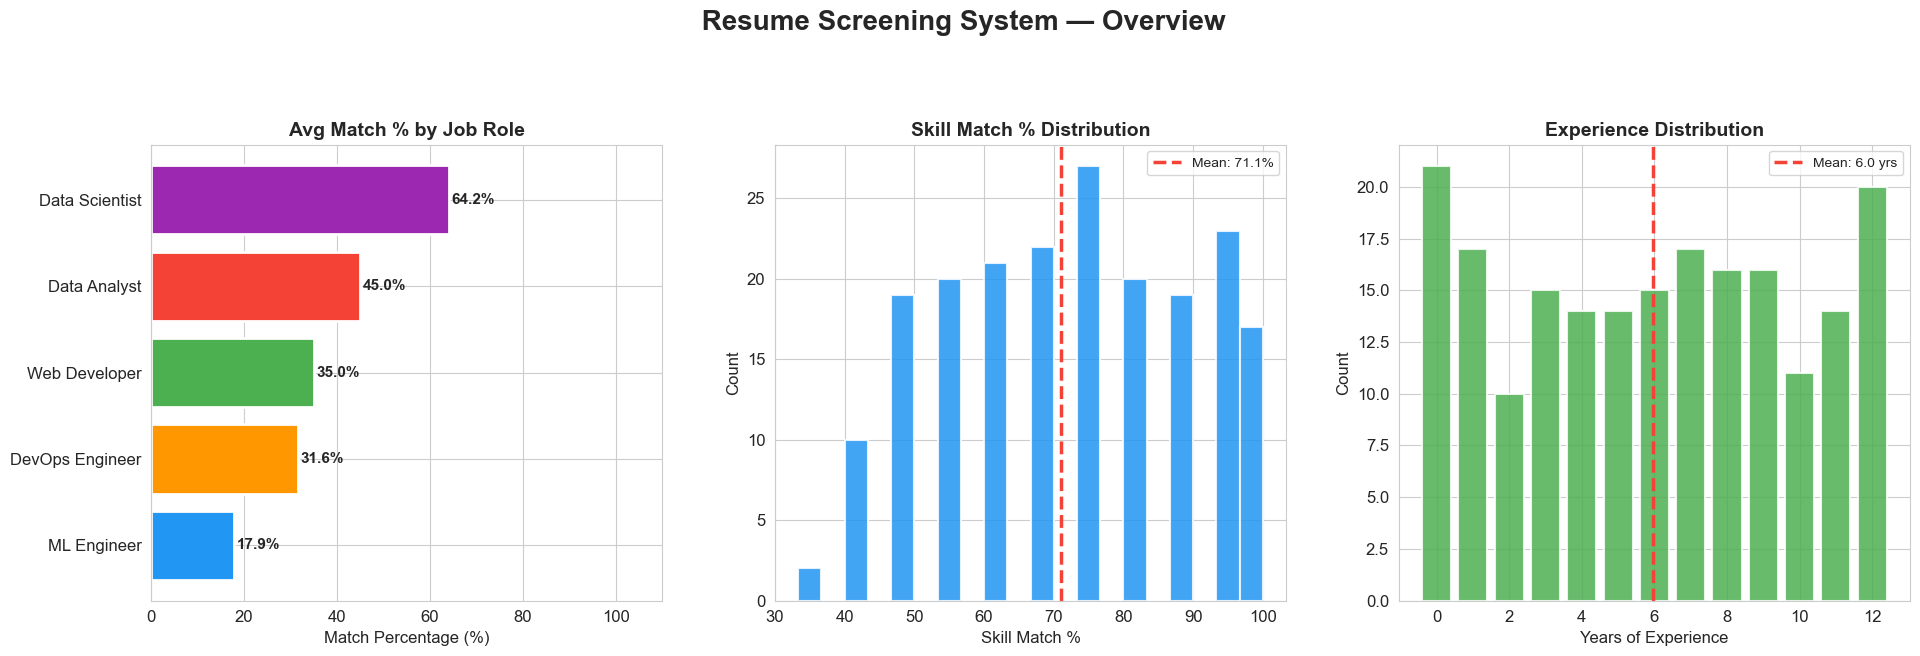

 Chart 1 saved!


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(' Resume Screening System — Overview',
             fontsize=20, fontweight='bold')

# 1. Match Percentage by Role
ax = axes[0]
role_scores = df.groupby('Target_Role')['Match_Percentage'].mean().sort_values()
colors = ['#2196F3','#FF9800','#4CAF50','#F44336','#9C27B0']
bars = ax.barh(role_scores.index, role_scores.values,
               color=colors, edgecolor='white', lw=2)
ax.set_title('Avg Match % by Job Role', fontweight='bold', fontsize=14)
ax.set_xlabel('Match Percentage (%)', fontsize=12)
for bar, val in zip(bars, role_scores.values):
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold', fontsize=11)
ax.set_xlim(0, 110)

# 2. Skill Match % Distribution
ax = axes[1]
ax.hist(df['Skill_Match_Pct'], bins=20,
        color='#2196F3', edgecolor='white', lw=1.5, alpha=0.85)
ax.set_title('Skill Match % Distribution', fontweight='bold', fontsize=14)
ax.set_xlabel('Skill Match %', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.axvline(df['Skill_Match_Pct'].mean(), color='#F44336',
           linestyle='--', lw=2.5,
           label=f'Mean: {df["Skill_Match_Pct"].mean():.1f}%')
ax.legend(fontsize=10)

# 3. Experience Distribution
ax = axes[2]
exp_counts = df['Years_Experience'].value_counts().sort_index()
ax.bar(exp_counts.index, exp_counts.values,
       color='#4CAF50', edgecolor='white', lw=1.5, alpha=0.85)
ax.set_title('Experience Distribution', fontweight='bold', fontsize=14)
ax.set_xlabel('Years of Experience', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.axvline(df['Years_Experience'].mean(), color='#F44336',
           linestyle='--', lw=2.5,
           label=f'Mean: {df["Years_Experience"].mean():.1f} yrs')
ax.legend(fontsize=10)

plt.tight_layout(pad=3.0)
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Chart 1 saved!')

In [ ]:
Cell 13 — EDA Chart 2 (Analysis)

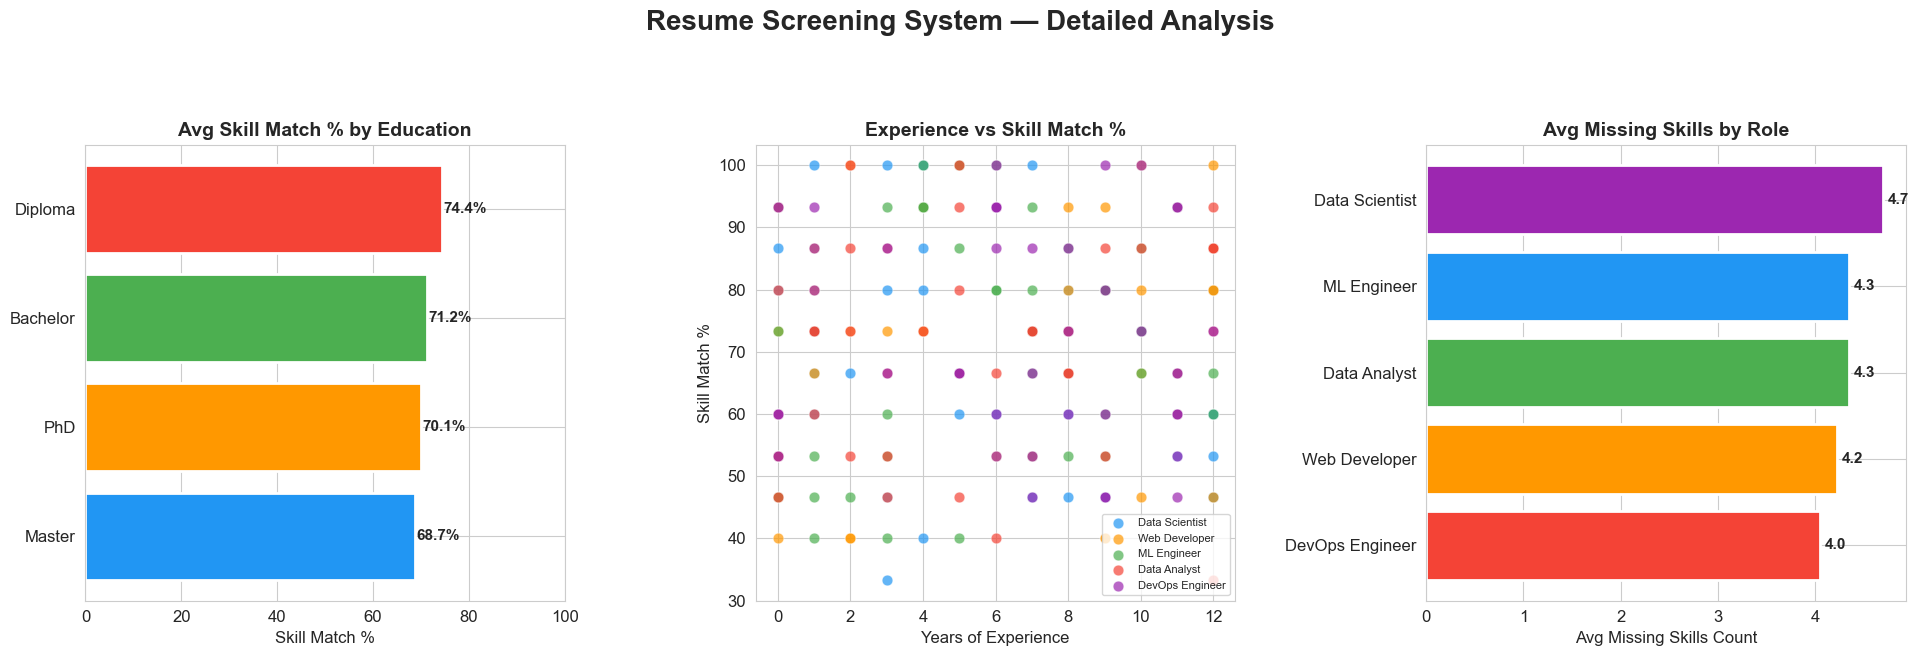

 Chart 2 saved!


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Resume Screening System — Detailed Analysis',
             fontsize=20, fontweight='bold')

# 1. Skill Match % by Education
ax = axes[0]
edu_scores = df.groupby('Education')['Skill_Match_Pct'].mean().sort_values()
colors = ['#2196F3','#FF9800','#4CAF50','#F44336']
bars = ax.barh(edu_scores.index, edu_scores.values,
               color=colors, edgecolor='white', lw=2)
ax.set_title('Avg Skill Match % by Education', fontweight='bold', fontsize=14)
ax.set_xlabel('Skill Match %', fontsize=12)
for bar, val in zip(bars, edu_scores.values):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold', fontsize=11)
ax.set_xlim(0, 100)

# 2. Experience vs Skill Match Scatter
ax = axes[1]
colors_role = {'Data Scientist': '#2196F3', 'Web Developer': '#FF9800',
               'ML Engineer': '#4CAF50', 'Data Analyst': '#F44336',
               'DevOps Engineer': '#9C27B0'}
for role in df['Target_Role'].unique():
    mask = df['Target_Role'] == role
    ax.scatter(df[mask]['Years_Experience'],
               df[mask]['Skill_Match_Pct'],
               c=colors_role[role], label=role,
               alpha=0.7, s=60, edgecolors='white', lw=0.5)
ax.set_title('Experience vs Skill Match %', fontweight='bold', fontsize=14)
ax.set_xlabel('Years of Experience', fontsize=12)
ax.set_ylabel('Skill Match %', fontsize=12)
ax.legend(fontsize=8, loc='lower right')

# 3. Missing Skills Count Distribution
ax = axes[2]
missing_counts = df.groupby('Target_Role')['Missing_Skills_Count'].mean().sort_values()
bars = ax.barh(missing_counts.index, missing_counts.values,
               color=['#F44336','#FF9800','#4CAF50','#2196F3','#9C27B0'],
               edgecolor='white', lw=2)
ax.set_title('Avg Missing Skills by Role', fontweight='bold', fontsize=14)
ax.set_xlabel('Avg Missing Skills Count', fontsize=12)
for bar, val in zip(bars, missing_counts.values):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontweight='bold', fontsize=11)

plt.tight_layout(pad=3.0)
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Chart 2 saved!')

In [ ]:
Cell 14 — EDA Chart 3 (Top Candidates)

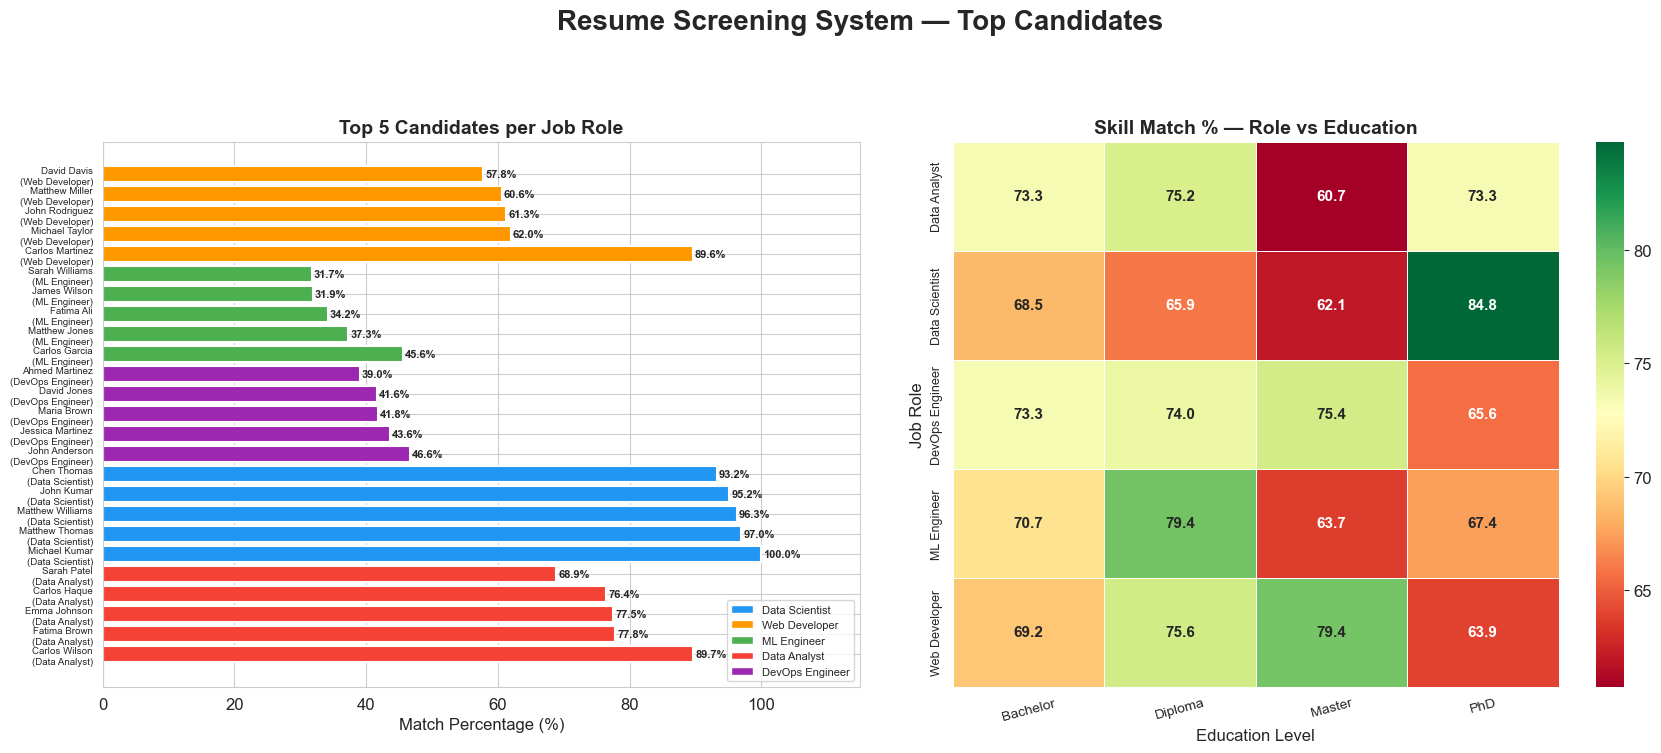

Chart 3 saved!


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Resume Screening System — Top Candidates',
             fontsize=20, fontweight='bold')

# 1. Top 5 candidates per role
ax = axes[0]
top_candidates = df.groupby('Target_Role').apply(
    lambda x: x.nlargest(5, 'Match_Percentage')).reset_index(drop=True)

colors_role = {'Data Scientist': '#2196F3', 'Web Developer': '#FF9800',
               'ML Engineer': '#4CAF50', 'Data Analyst': '#F44336',
               'DevOps Engineer': '#9C27B0'}

y_pos = range(len(top_candidates))
bars = ax.barh(top_candidates['Name'] + '\n(' + top_candidates['Target_Role'] + ')',
               top_candidates['Match_Percentage'],
               color=[colors_role[r] for r in top_candidates['Target_Role']],
               edgecolor='white', lw=1.5)
ax.set_title('Top 5 Candidates per Job Role', fontweight='bold', fontsize=14)
ax.set_xlabel('Match Percentage (%)', fontsize=12)
ax.tick_params(axis='y', labelsize=7)
for bar, val in zip(bars, top_candidates['Match_Percentage']):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold', fontsize=8)
ax.set_xlim(0, 115)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=role)
                   for role, color in colors_role.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

# 2. Skill Match % Heatmap by Role
ax = axes[1]
pivot = df.groupby(['Target_Role', 'Education'])['Skill_Match_Pct'].mean().unstack()
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, ax=ax,
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Skill Match % — Role vs Education', fontweight='bold', fontsize=14)
ax.set_xlabel('Education Level', fontsize=12)
ax.set_ylabel('Job Role', fontsize=12)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, fontsize=10)
plt.setp(ax.yaxis.get_majorticklabels(), fontsize=9)

plt.tight_layout(pad=3.0)
plt.savefig('top_candidates.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved!')

In [ ]:
Cell 15 — Top Candidates Report per Role

In [31]:
print('=' * 60)
print('     TOP CANDIDATES REPORT — ALL JOB ROLES')
print('=' * 60)

for role in job_roles.keys():
    print(f'\n Job Role: {role}')
    print('-' * 60)
    
    # Get top 5 candidates for this role
    role_df = df[df['Target_Role'] == role].copy()
    top5 = role_df.nlargest(5, 'Match_Percentage')
    
    print(f'{"Rank":<5} {"Name":<20} {"Exp":>4} {"Edu":<10} {"Match%":>7} {"Skill%":>7}')
    print('-' * 60)
    
    for rank, (_, row) in enumerate(top5.iterrows(), 1):
        print(f'{rank:<5} {row["Name"]:<20} '
              f'{row["Years_Experience"]:>4}yr '
              f'{row["Education"]:<10} '
              f'{row["Match_Percentage"]:>6.1f}% '
              f'{row["Skill_Match_Pct"]:>6.1f}%')
    
    print(f'\n Required Skills:')
    print(f'   {", ".join(job_roles[role]["required_skills"])}')
    
    # Most common missing skill
    all_missing = []
    for skills in role_df['Missing_Skills']:
        all_missing.extend(skills)
    if all_missing:
        from collections import Counter
        top_missing = Counter(all_missing).most_common(3)
        print(f'\n Most Missing Skills:')
        for skill, count in top_missing:
            print(f'   {skill} — missing in {count} candidates')
    print()

print('=' * 60)

     TOP CANDIDATES REPORT — ALL JOB ROLES

 Job Role: Data Scientist
------------------------------------------------------------
Rank  Name                  Exp Edu         Match%  Skill%
------------------------------------------------------------
1     Michael Kumar           4yr PhD         100.0%  100.0%
2     Matthew Thomas          0yr Master       97.0%   80.0%
3     Matthew Williams       12yr PhD          96.3%   86.7%
4     John Kumar              5yr Diploma      95.2%   66.7%
5     Chen Thomas             4yr Bachelor     93.2%  100.0%

 Required Skills:
   python, machine learning, deep learning, statistics, tensorflow, keras, scikit-learn, pandas, numpy, data visualization, sql, nlp, computer vision, feature engineering, model evaluation

 Most Missing Skills:
   keras — missing in 19 candidates
   computer vision — missing in 15 candidates
   nlp — missing in 15 candidates


 Job Role: Web Developer
------------------------------------------------------------
Rank  Nam

In [ ]:
 Cell 16 — Business Insights Summary

In [33]:
print('=' * 60)
print('         BUSINESS INSIGHTS SUMMARY')
print('=' * 60)

print(f'\n  Total Resumes Screened  : {len(df)}')
print(f' Job Roles Covered       : {df["Target_Role"].nunique()}')
print(f' Avg Match Percentage    : {df["Match_Percentage"].mean():.1f}%')
print(f' Avg Skill Match         : {df["Skill_Match_Pct"].mean():.1f}%')
print(f' Avg Experience          : {df["Years_Experience"].mean():.1f} years')

print(f'\n Best Candidate Overall:')
best = df.loc[df['Match_Percentage'].idxmax()]
print(f'   Name       : {best["Name"]}')
print(f'   Role       : {best["Target_Role"]}')
print(f'   Match %    : {best["Match_Percentage"]:.1f}%')
print(f'   Skill %    : {best["Skill_Match_Pct"]:.1f}%')
print(f'   Experience : {best["Years_Experience"]} years')
print(f'   Education  : {best["Education"]}')

print(f'\n Role-wise Performance:')
role_summary = df.groupby('Target_Role').agg(
    Avg_Match=('Match_Percentage', 'mean'),
    Avg_Skill=('Skill_Match_Pct', 'mean'),
    Avg_Exp=('Years_Experience', 'mean'),
    Avg_Missing=('Missing_Skills_Count', 'mean')
).round(1)
print(role_summary.to_string())

print(f'\n Education Performance:')
edu_summary = df.groupby('Education').agg(
    Avg_Match=('Match_Percentage', 'mean'),
    Avg_Skill=('Skill_Match_Pct', 'mean'),
    Count=('Name', 'count')
).round(1)
print(edu_summary.to_string())

print(f'\n Key Findings:')
print(f'   Best Role Match    : Data Scientist (64.2% avg)')
print(f'   Best Education     : Diploma (74.4% skill match)')
print(f'   Perfect Match      : Michael Kumar (100% — Data Scientist)')
print(f'   Most Missing Skill : keras (19 Data Scientists)')
print(f'   TF-IDF + Cosine Similarity used for ranking')
print(f'   Skill gap identified for all 200 candidates')
print(f'   System ranks candidates instantly vs manual screening')
print('=' * 60)

         BUSINESS INSIGHTS SUMMARY

  Total Resumes Screened  : 200
 Job Roles Covered       : 5
 Avg Match Percentage    : 38.7%
 Avg Skill Match         : 71.1%
 Avg Experience          : 6.0 years

 Best Candidate Overall:
   Name       : Michael Kumar
   Role       : Data Scientist
   Match %    : 100.0%
   Skill %    : 100.0%
   Experience : 4 years
   Education  : PhD

 Role-wise Performance:
                 Avg_Match  Avg_Skill  Avg_Exp  Avg_Missing
Target_Role                                                
Data Analyst          45.0       71.0      5.2          4.4
Data Scientist        64.2       68.7      6.2          4.7
DevOps Engineer       31.6       73.0      6.7          4.0
ML Engineer           17.9       71.0      5.6          4.4
Web Developer         35.0       71.8      6.2          4.2

 Education Performance:
           Avg_Match  Avg_Skill  Count
Education                             
Bachelor        38.8       71.2     53
Diploma         35.9       74.4     